False


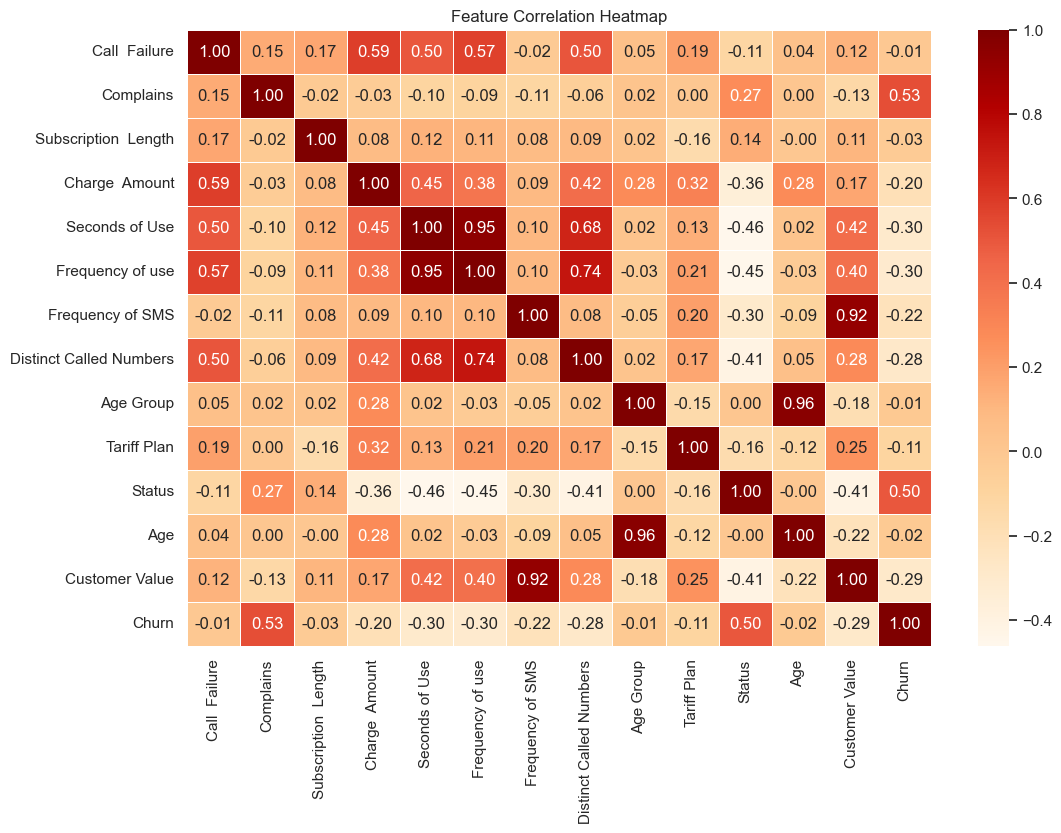

C:\Users\tough\AppData\Local\Temp\ipykernel_14748\3169509567.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette="pastel")


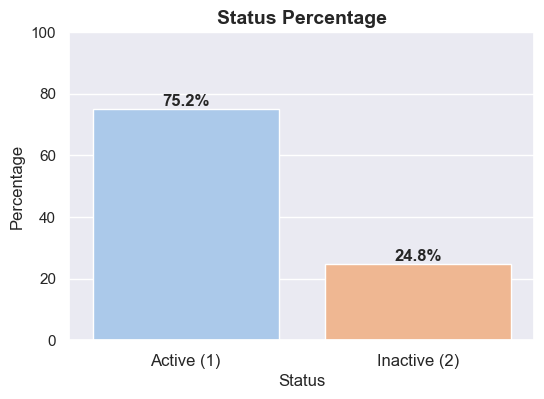

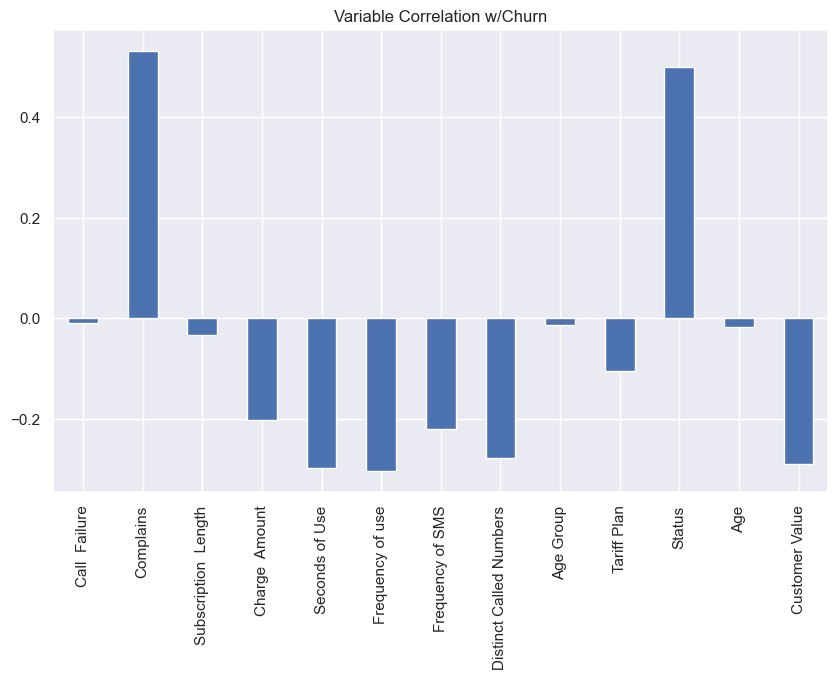

0.9259259259259259
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       810
           1       0.72      0.80      0.76       135

    accuracy                           0.93       945
   macro avg       0.84      0.87      0.86       945
weighted avg       0.93      0.93      0.93       945



C:\Users\tough\AppData\Local\Temp\ipykernel_14748\3169509567.py:234: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=feat_importance['Importance'], y=feat_importance['Feature'], palette='Blues_r')


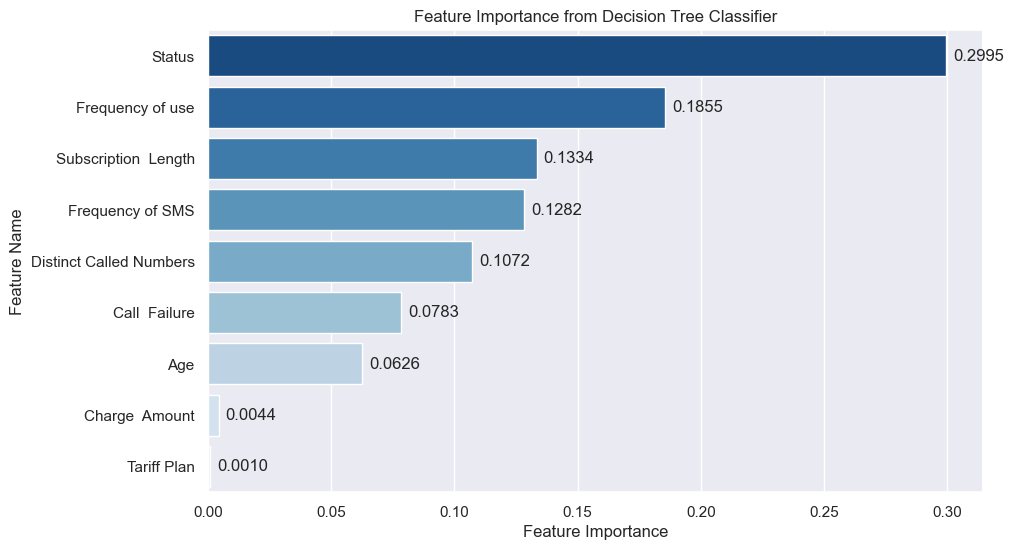

Cluster Counts:
 Churn_Cluster
1    396
2    860
3    305
4    401
5    778
6    410
Name: count, dtype: int64


C:\Users\tough\AppData\Local\Temp\ipykernel_14748\3169509567.py:267: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=churn_rates.index, y=churn_rates.values, palette="coolwarm")


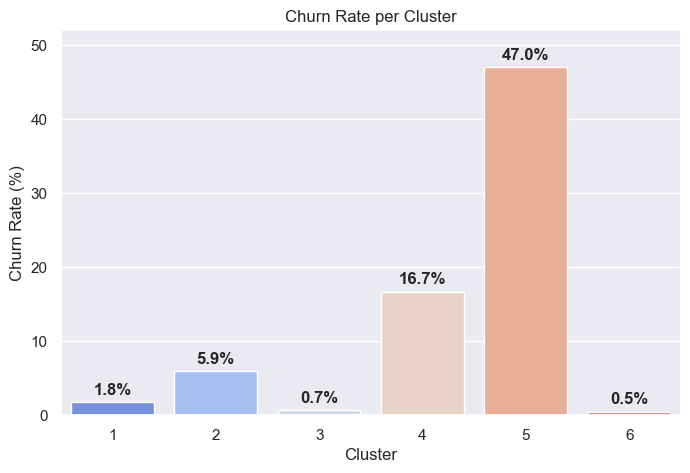

,Status,Frequency of use,Subscription Length,Frequency of SMS,Distinct Called Numbers,Call Failure,Age
Churn_Cluster,,,,,,,
1,1.00,82.81,31.12,26.30,33.83,8.83,49.29
2,1.00,77.29,36.05,35.32,25.11,6.42,26.43
3,1.00,183.80,34.18,67.31,47.96,19.48,27.18
4,1.00,37.20,16.72,66.81,13.64,4.40,27.66
5,2.00,23.97,34.74,15.28,11.08,6.15,30.98
6,1.00,72.96,36.65,318.30,25.23,6.16,29.06



Churn Rate per Cluster:
Churn_Cluster
1    1.77
2    5.93
3    0.66
4   16.71
5   47.04
6    0.49 %
Cluster Summary (Mean):


,Status,Frequency of use,Subscription Length,Frequency of SMS,Distinct Called Numbers,Call Failure,Age
Churn_Cluster,,,,,,,
1,1.002525,82.810606,31.121212,26.303030,33.828283,8.830808,49.292929
2,1.000000,77.289535,36.046512,35.316279,25.110465,6.418605,26.430233
3,1.003279,183.800000,34.180328,67.314754,47.963934,19.475410,27.180328
4,1.004988,37.197007,16.718204,66.810474,13.643392,4.396509,27.655860
5,2.000000,23.970437,34.741645,15.282776,11.078406,6.146530,30.976864
6,1.000000,72.963415,36.646341,318.295122,25.234146,6.160976,29.060976



Cluster Summary (Median):


,Status,Frequency of use,Subscription Length,Frequency of SMS,Distinct Called Numbers,Call Failure,Age
Churn_Cluster,,,,,,,
1,1.0,88.0,34.0,18.0,37.0,7.0,45.0
2,1.0,75.0,36.0,12.0,25.0,6.0,25.0
3,1.0,185.0,37.0,54.0,44.0,19.0,25.0
4,1.0,33.0,17.0,26.0,12.0,3.0,30.0
5,2.0,19.0,35.0,10.5,9.0,5.0,30.0
6,1.0,63.0,37.0,298.0,25.0,6.0,30.0


In [ ]:
#import packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap 
import sys
print("ace_tools" in sys.modules)
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import tree
from sklearn.tree import export_graphviz
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix,classification_report
from collections import Counter
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display
%matplotlib inline
sns.set_theme(color_codes=True)
import graphviz
shap.initjs()

#load data
data = pd.read_csv('CustomerChurn.csv')
#display first 5 rows
##data.head(5)
#display bottom 5 rows
##data.tail(5)

#check data types
##data.dtypes

#get basic statistics on every variable
#data.describe()

#Histogram & Distribution for numeric variables
#cols = data[['Call  Failure', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age', 'Customer Value']]

#fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 10))
#axes = axes.flatten()

#for i, col in enumerate(cols):
#    sns.histplot(data=data, x=col, bins=30, ax=axes[i])
#    axes[i].set_ylabel("Count")

#plt.tight_layout()
#plt.show()

#KDE graphs to show distribution
#for i, col in enumerate(cols):
#    sns.kdeplot(data=data, x=col, fill=True, ax=axes[i], alpha=0.6, linewidth=2)

#plt.tight_layout()
#plt.show()

#heatmap
corr_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="OrRd", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# churn percentage bar graph
#churn_counts = data['Churn'].value_counts(normalize=True) * 100
#plt.figure(figsize=(6,4))
#ax = sns.barplot(x=churn_counts.index, y=churn_counts.values, palette="pastel")
#for i, p in enumerate(churn_counts.values):
#    ax.text(i, p + 1, f"{p:.1f}%", ha='center', fontsize=12, fontweight='bold')
#plt.title("Churn Percentage", fontsize=14, fontweight='bold')
#plt.xlabel("Churn", fontsize=12)
#plt.ylabel("Percentage", fontsize=12)
#plt.xticks(ticks=[0,1], labels=["Stayed (0)", "Churned (1)"], fontsize=12)
#plt.ylim(0, 100)  # Set y-axis limit to 100%
#plt.show()

# complains percentage bar graph
#complains_counts = data['Complains'].value_counts(normalize=True) * 100
#plt.figure(figsize=(6,4))
#ax = sns.barplot(x=complains_counts.index, y=complains_counts.values, palette="pastel")
#for i, p in enumerate(complains_counts.values):
#    ax.text(i, p + 1, f"{p:.1f}%", ha='center', fontsize=12, fontweight='bold')
#plt.title("Complains Percentage", fontsize=14, fontweight='bold')
#plt.xlabel("Complains", fontsize=12)
#plt.ylabel("Percentage", fontsize=12)
#plt.xticks(ticks=[0,1], labels=["No Complaint (0)", "Complaint (1)"], fontsize=12)
#plt.ylim(0, 100)  # Set y-axis limit to 100%
#plt.show()

# status percentage bar graph
status_counts = data['Status'].value_counts(normalize=True) * 100
plt.figure(figsize=(6,4))
ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette="pastel")
for i, p in enumerate(status_counts.values):
    ax.text(i, p + 1, f"{p:.1f}%", ha='center', fontsize=12, fontweight='bold')
plt.title("Status Percentage", fontsize=14, fontweight='bold')
plt.xlabel("Status", fontsize=12)
plt.ylabel("Percentage", fontsize=12)
plt.xticks(ticks=[0,1], labels=["Active (1)", "Inactive (2)"], fontsize=12)
plt.ylim(0, 100)  # Set y-axis limit to 100%
plt.show()

#feature correlation
data.drop('Churn',axis=1).corrwith(data.Churn).plot(kind='bar',grid=True,figsize=(10,6),title="Variable Correlation w/Churn")
plt.show()

#drop highly correlated variables
data = data.drop(columns=['Customer Value', 'Age Group', 'Complains', 'Seconds of Use'])



#run preliminary classification tree
#split dataset into feature and target variable(s)
X = data.drop(columns=['Churn']) # dropping Churn and setting all other columns as features
y = data['Churn'] #Churn as target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) #70-30 train-test split

#creating decision tree classifier object
clf = DecisionTreeClassifier(max_depth=12, random_state=1)

#train decision tree classifier
clf = clf.fit(X_train, y_train)

#prediction
y_pred = clf.predict(X_test)

#check model accuracy
print(metrics.accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
#plot classification tree
dot_data = export_graphviz(
    clf, out_file=None, filled=True, feature_names=X.columns, class_names=['No Churn', 'Churn']
)
graph = graphviz.Source(dot_data)
graph.render("decision_tree") 
#graph

#confusion matrix
#cm = confusion_matrix(y_test, y_pred)
#sns.heatmap(cm, 
#            annot=True,
#            fmt='g', 
#            xticklabels=['Churn','Not Churn'],
#            yticklabels=['Churn','Not Churn'])
#plt.ylabel('Actual', fontsize=13)
#plt.title('Confusion Matrix', fontsize=17, pad=20)
#plt.gca().xaxis.set_label_position('top') 
#plt.xlabel('Prediction', fontsize=13)
#plt.gca().xaxis.tick_top()

#plt.gca().figure.subplots_adjust(bottom=0.2)
#plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
#plt.show()

#show columns
#print(data.columns)

#path = clf.cost_complexity_pruning_path(X_train, y_train)
#alphas = path['ccp_alphas']

#alphas 

#clfs = []  # Initialize an empty list for pruned trees

#for alpha in alphas:
#    pruned_clf = DecisionTreeClassifier(random_state=1, ccp_alpha=alpha)
#    pruned_clf.fit(X_train, y_train)
#    clfs.append(pruned_clf)  # Store pruned model

#train_scores = []
#test_scores = []

#for clf in clfs:
#    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
#    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Plot train vs. test accuracy
#plt.figure(figsize=(8, 5))
#plt.plot(alphas, train_scores, marker="o", label="Train Accuracy")
#plt.plot(alphas, test_scores, marker="o", label="Test Accuracy")
#plt.xlabel("Alpha (Pruning Strength)")
#plt.ylabel("Accuracy")
#plt.title("Train vs. Test Accuracy with Different ccp_alphas")
#plt.legend()
#plt.xscale("log")
#plt.show()

# Define hyperparameter grid with dynamic sampling
#param_grid = {
#    'criterion': ['gini', 'entropy'],
#    'max_depth': randint(3, 30),  # Random depth between 3 and 30
#    'min_samples_split': randint(2, 20),  # Random split values
#    'min_samples_leaf': randint(1, 10),  # Random leaf sizes
#    'ccp_alpha': [0.0001, 0.001, 0.002, 0.005, 0.01]  # Fixed list
#}

# Perform Randomized Search
#random_search = RandomizedSearchCV(
#    estimator=clf,
#    param_distributions=param_grid,
#    n_iter=15,  # Number of random samples to test
#    cv=5,  # Cross-validation folds
#    scoring='accuracy',
#    random_state=1,
#    n_jobs=-1
#)

# Train Randomized Search
#random_search.fit(X_train, y_train)

# Get best parameters and best model
#best_params = random_search.best_params_
#best_clf = random_search.best_estimator_

# Evaluate best model
#y_pred_best = best_clf.predict(X_test)
#final_accuracy = accuracy_score(y_test, y_pred_best)

# Print results
#print(f"Best Parameters: {best_params}")
#print(f"Final Test Accuracy: {final_accuracy:.4f}")


importances = clf.feature_importances_
feat_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=feat_importance['Importance'], y=feat_importance['Feature'], palette='Blues_r')
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5)
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.title('Feature Importance from Decision Tree Classifier')
plt.show()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select top features for clustering
top_features = feat_importance['Feature'].head(7).tolist()
clustering_data = data[top_features]

# Standardize the data
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

# Perform K-Means clustering
optimal_k = 6  # Adjust based on elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=1, n_init=10)
data['Churn_Cluster'] = kmeans.fit_predict(clustering_data_scaled)

# Convert cluster labels to 1-based index (1 to 6 instead of 0 to 5)
data['Churn_Cluster'] += 1  

# Check cluster counts
print("Cluster Counts:\n", data['Churn_Cluster'].value_counts().sort_index())

# Bar plot of churn rate per cluster
plt.figure(figsize=(8, 5))
churn_rates = data.groupby('Churn_Cluster')['Churn'].mean() * 100  # Convert to percentage
ax = sns.barplot(x=churn_rates.index, y=churn_rates.values, palette="coolwarm")

# Add labels to bars
for i, rate in enumerate(churn_rates.values):
    ax.text(i, rate + 1, f"{rate:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.xlabel("Cluster")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate per Cluster")
plt.ylim(0, max(churn_rates.values) + 5)  # Adjust y-limit
plt.show()

# Compute and display summary statistics per cluster
cluster_summary = data.groupby('Churn_Cluster')[top_features].mean()
display(cluster_summary.style.format("{:.2f}"))

# Print churn rate per cluster with 1-based indexing
print("\nChurn Rate per Cluster:")
print(churn_rates.to_string(float_format="%.2f") + " %")



# Compute mean and median for key features
features_to_check = ['Status', 'Frequency of use', 'Subscription  Length', 'Frequency of SMS', 
                     'Distinct Called Numbers', 'Call  Failure', 'Age']

# Group by cluster and compute statistics
cluster_summary_mean = data.groupby('Churn_Cluster')[features_to_check].mean()
cluster_summary_median = data.groupby('Churn_Cluster')[features_to_check].median()

# Display both tables
print("Cluster Summary (Mean):")
display(cluster_summary_mean)

print("\nCluster Summary (Median):")
display(cluster_summary_median)

